In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import stats
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)   # hides harmless warnings from empty cells
%matplotlib inline

DATA_FILE = "Ghana_CHIRPS_SoilTemperature_2005_2020_clean.nc"
ZONE_FILE = "ghanaAEZ.geojson"

DRY_LIMIT = -1.0    # dry  month: rainfall z-score <= -1
HOT_LIMIT = 1.0     # hot  month: soil-temperature z-score >= +1

In [10]:
ds = xr.open_dataset(DATA_FILE)

rain  = ds["rainfall"]
soilT = ds["soil_temperature"]
lat = ds["latitude"].values
lon = ds["longitude"].values

ds

<xarray.Dataset> Size: 937kB
Dimensions:           (time: 192, latitude: 29, longitude: 21)
Coordinates:
  * time              (time) datetime64[ns] 2kB 2005-01-01 ... 2020-12-01
  * latitude          (latitude) float64 232B 11.5 11.25 11.0 ... 5.0 4.75 4.5
  * longitude         (longitude) float64 168B -3.5 -3.25 -3.0 ... 1.0 1.25 1.5
    number            int64 8B ...
Data variables:
    rainfall          (time, latitude, longitude) float32 468kB ...
    soil_temperature  (time, latitude, longitude) float32 468kB ...

EPSG:4326
   id                    Name
0   1         Coastal savanna
1   2           Wet evergreen
2   3         Moist evergreen
3   5        Deciduous forest
4   4       Transitional zone
5   6          Guinea savanna
6   7           Sudan savanna
7   8  Waterbody - Volta lake


/var/folders/00/0gdt6xhn1td1wnchds595qjw0000gn/T/ipykernel_3345/1284895924.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ghana = aez.dissolve().buffer(0.02).buffer(-0.02)


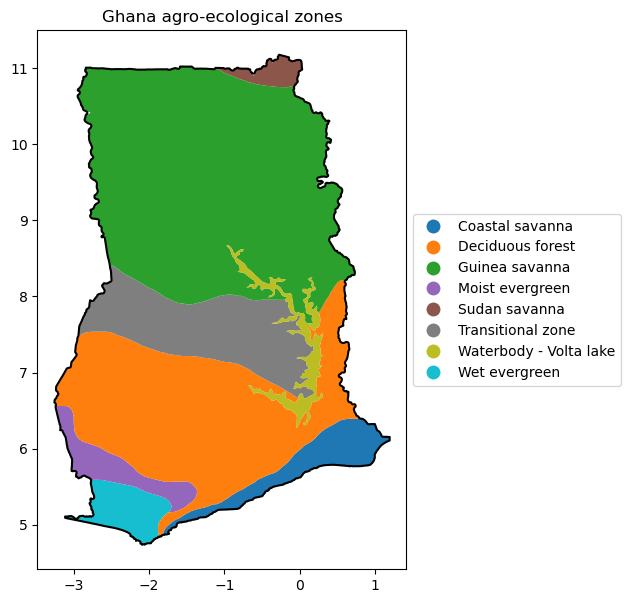

In [11]:
aez = gpd.read_file(ZONE_FILE)
aez["Name"] = aez["Name"].replace({"Decidous forest": "Deciduous forest"})   # fix spelling in the file

# merge all zones into ONE polygon = Ghana's outline.
# (the tiny buffer out-and-back closes hairline gaps between neighbouring zone polygons)
ghana = aez.dissolve().buffer(0.02).buffer(-0.02)
minx, miny, maxx, maxy = aez.total_bounds    # bounding box of Ghana, used to zoom every map

print(aez.crs)
print(aez[["id", "Name"]])

fig, ax = plt.subplots(figsize=(6, 7))
aez.plot(ax=ax, column="Name", cmap="tab10", legend=True,
         legend_kwds={"loc": "center left", "bbox_to_anchor": (1, 0.5)})
ghana.boundary.plot(ax=ax, color="black", linewidth=1.5)
ax.set_title("Ghana agro-ecological zones")
plt.show()

In [12]:
def add_outline(ax):
    """Draw zone borders + Ghana's outline on a map and zoom to Ghana."""
    aez.boundary.plot(ax=ax, color="grey", linewidth=0.5)
    ghana.boundary.plot(ax=ax, color="black", linewidth=1.5)
    ax.set_xlim(minx - 0.2, maxx + 0.2)
    ax.set_ylim(miny - 0.2, maxy + 0.2)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

In [13]:
# centre point of every grid cell
lon2d, lat2d = np.meshgrid(lon, lat)
points = gpd.GeoDataFrame({"cell": np.arange(lon2d.size)},
                          geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
                          crs="EPSG:4326")

# which zone polygon is each point inside?  (points outside Ghana get no zone)
matched = gpd.sjoin(points, aez[["Name", "geometry"]], how="left", predicate="within")
matched = matched.drop_duplicates("cell").sort_values("cell")

zone_name = xr.DataArray(matched["Name"].values.reshape(lat2d.shape),
                         coords={"latitude": lat, "longitude": lon},
                         dims=("latitude", "longitude"))

print(matched["Name"].value_counts())

Name
Guinea savanna            143
Deciduous forest           86
Transitional zone          38
Moist evergreen            11
Wet evergreen              11
Coastal savanna            10
Waterbody - Volta lake      6
Sudan savanna               4
Name: count, dtype: int64


In [14]:
inside_ghana = zone_name.notnull() & (zone_name != "Waterbody - Volta lake")   # drop cells outside Ghana and the lake
has_rain     = rain.notnull().all("time") & (rain.sum("time") > 0)            # drop missing / zero-filled ocean cells
valid = inside_ghana & has_rain

print("Grid cells kept:", int(valid.sum()), "of", valid.size)

rain  = rain.where(valid)       # everything outside Ghana becomes empty (NaN)
soilT = soilT.where(valid)

Grid cells kept: 302 of 609


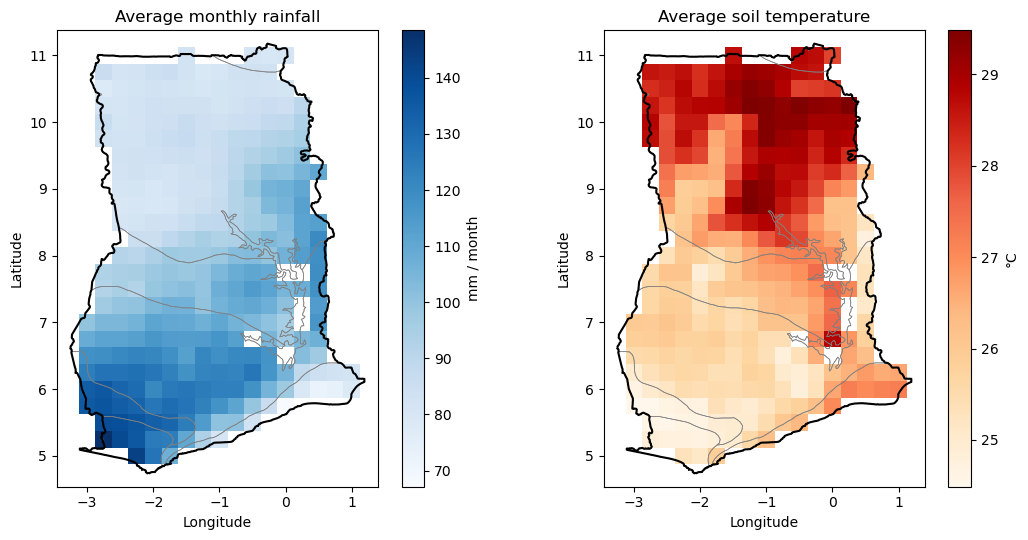

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

rain.mean("time").plot(ax=axes[0], cmap="Blues", cbar_kwargs={"label": "mm / month"})
axes[0].set_title("Average monthly rainfall")
add_outline(axes[0])

soilT.mean("time").plot(ax=axes[1], cmap="OrRd", cbar_kwargs={"label": "°C"})
axes[1].set_title("Average soil temperature")
add_outline(axes[1])

plt.tight_layout()
plt.show()

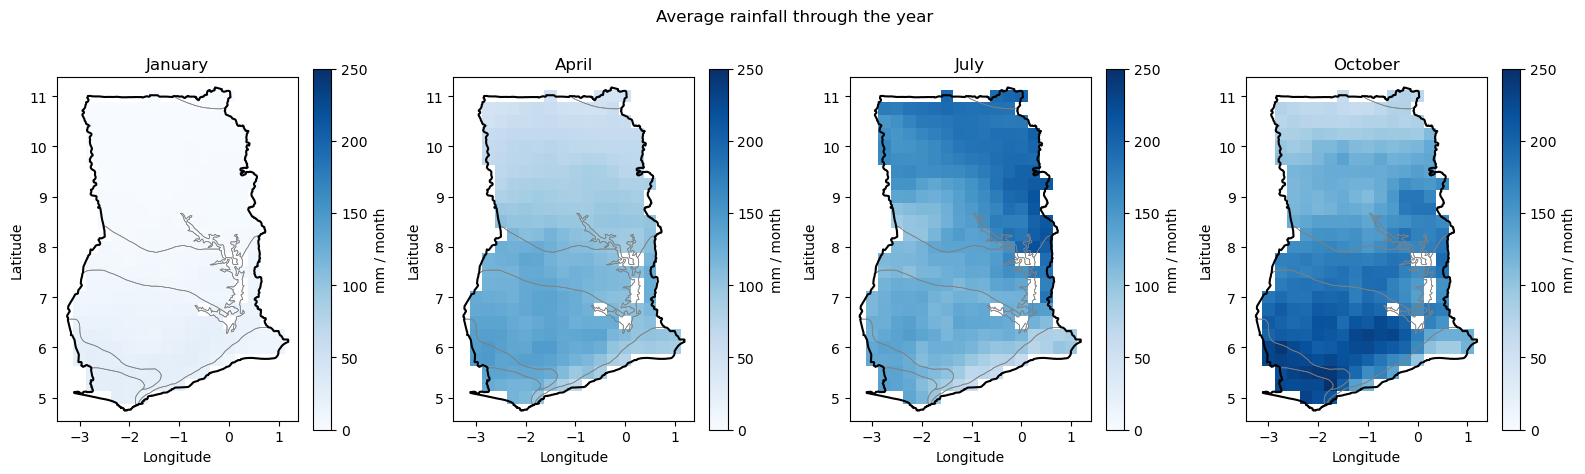

In [16]:
rain_clim  = rain.groupby("time.month").mean("time")      # average January, February, ... per cell
soilT_clim = soilT.groupby("time.month").mean("time")

months = [1, 4, 7, 10]
names  = ["January", "April", "July", "October"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, m, name in zip(axes, months, names):
    rain_clim.sel(month=m).plot(ax=ax, cmap="Blues", vmin=0, vmax=250,
                                cbar_kwargs={"label": "mm / month"})
    ax.set_title(name)
    add_outline(ax)
plt.suptitle("Average rainfall through the year", y=1.02)
plt.tight_layout()
plt.show()

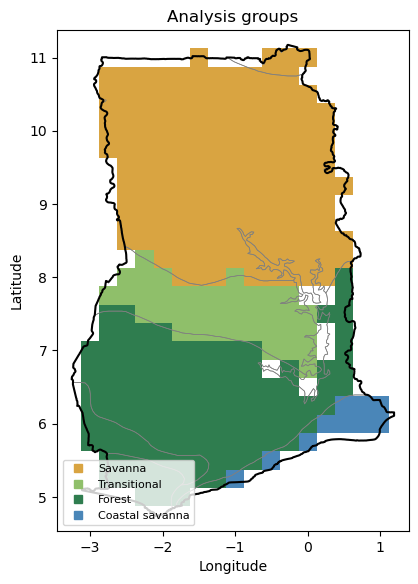

Savanna            147
Forest             107
Transitional        38
Coastal savanna     10
Name: count, dtype: int64


In [17]:
group_of = {
    "Guinea savanna":    "Savanna",
    "Sudan savanna":     "Savanna",
    "Transitional zone": "Transitional",
    "Deciduous forest":  "Forest",
    "Moist evergreen":   "Forest",
    "Wet evergreen":     "Forest",
    "Coastal savanna":   "Coastal savanna",
}
group_names = ["Savanna", "Transitional", "Forest", "Coastal savanna"]      # north -> south
colors = {"Savanna": "#d9a441", "Transitional": "#8fbf6a", "Forest": "#2f7d4f", "Coastal savanna": "#4a86b8"}

matched["group"] = matched["Name"].map(group_of)
group_map = xr.DataArray(matched["group"].values.reshape(lat2d.shape),
                         coords={"latitude": lat, "longitude": lon},
                         dims=("latitude", "longitude"))

# number the groups 0..3 so we can colour them on a map
group_num = xr.full_like(valid, np.nan, dtype=float)
for i, name in enumerate(group_names):
    group_num = xr.where((group_map == name) & valid, i, group_num)

fig, ax = plt.subplots(figsize=(5.5, 6.5))
group_num.plot(ax=ax, cmap=ListedColormap([colors[n] for n in group_names]),
               vmin=-0.5, vmax=3.5, add_colorbar=False)
for name in group_names:
    ax.plot([], [], "s", color=colors[name], label=name)     # empty points, just for the legend
ax.legend(loc="lower left", fontsize=8)
ax.set_title("Analysis groups")
add_outline(ax)
plt.show()

print(group_map.where(valid).to_series().value_counts())

In [18]:
# soil temperature z-score: how unusual is this month compared with the same calendar month in other years?
T_mean = soilT.groupby("time.month").mean("time")
T_std  = soilT.groupby("time.month").std("time")
soilT_z = (soilT.groupby("time.month") - T_mean).groupby("time.month") / T_std

# rainfall: add up 3 consecutive months first, then z-score
rain3  = rain.rolling(time=3, min_periods=3).sum()
R_mean = rain3.groupby("time.month").mean("time")
R_std  = rain3.groupby("time.month").std("time")
rain_z = (rain3.groupby("time.month") - R_mean).groupby("time.month") / R_std

print("done")

done


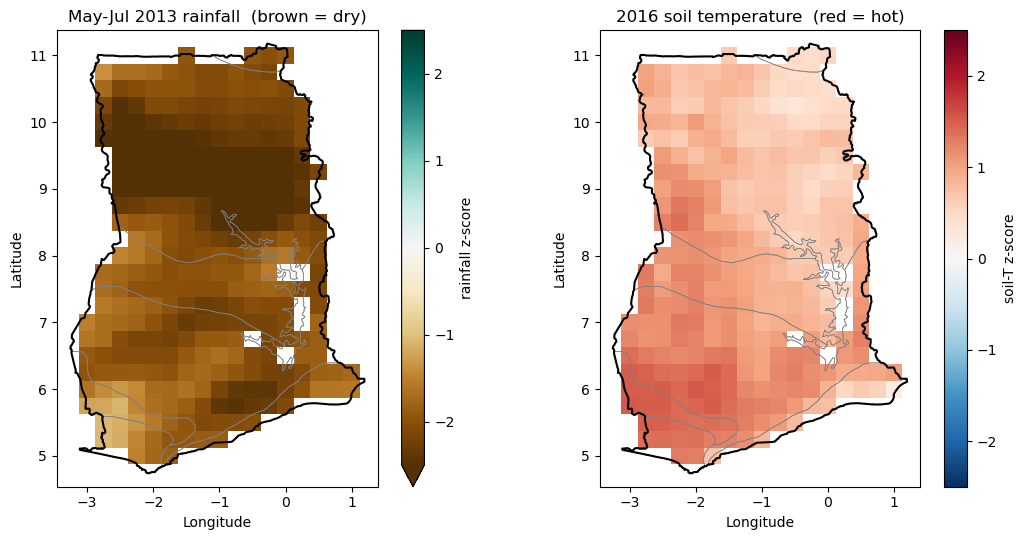

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# July 2013: a widespread drought
rain_z.sel(time="2013-07-01").plot(ax=axes[0], cmap="BrBG", vmin=-2.5, vmax=2.5,
                                   cbar_kwargs={"label": "rainfall z-score"})
axes[0].set_title("May-Jul 2013 rainfall  (brown = dry)")
add_outline(axes[0])

# the whole of 2016: the hottest year
soilT_z.sel(time=slice("2016-01-01", "2016-12-31")).mean("time").plot(
    ax=axes[1], cmap="RdBu_r", vmin=-2.5, vmax=2.5, cbar_kwargs={"label": "soil-T z-score"})
axes[1].set_title("2016 soil temperature  (red = hot)")
add_outline(axes[1])

plt.tight_layout()
plt.show()

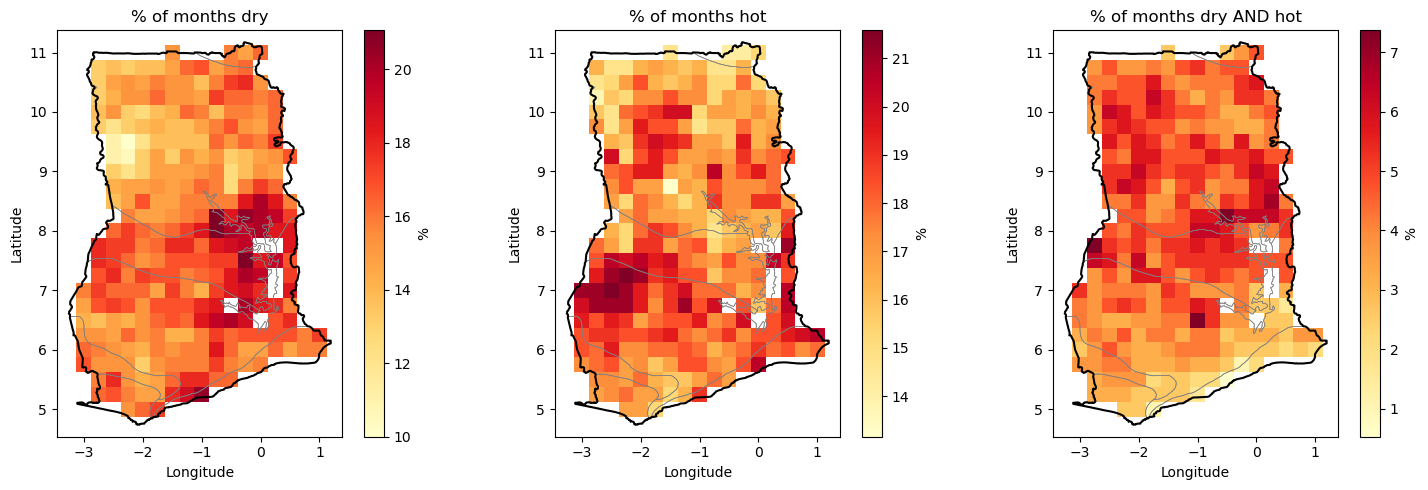

In [20]:
usable = rain_z.notnull()                     # months where the 3-month rainfall exists

dry  = (rain_z  <= DRY_LIMIT).where(usable)   # 1 = dry,  0 = not dry
hot  = (soilT_z >= HOT_LIMIT).where(usable)   # 1 = hot,  0 = not hot
both = dry * hot                              # 1 only if dry AND hot

freq_dry  = dry.mean("time")  * 100           # % of months in each cell
freq_hot  = hot.mean("time")  * 100
freq_both = both.mean("time") * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, title in zip(axes, [freq_dry, freq_hot, freq_both],
                           ["% of months dry", "% of months hot", "% of months dry AND hot"]):
    data.plot(ax=ax, cmap="YlOrRd", cbar_kwargs={"label": "%"})
    ax.set_title(title)
    add_outline(ax)
plt.tight_layout()
plt.show()

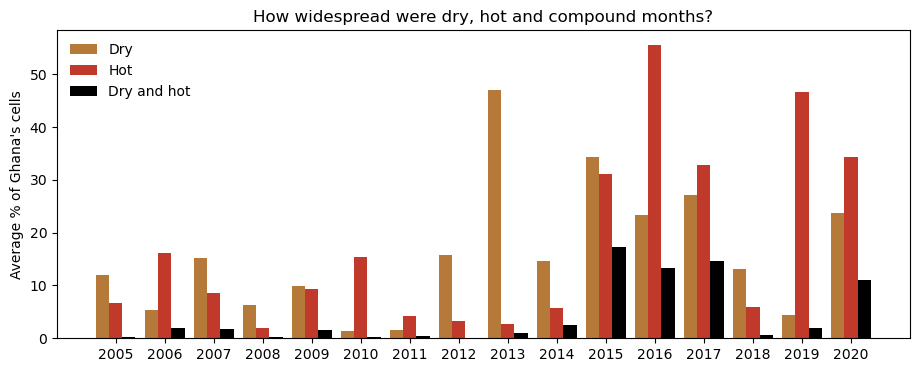

,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
dry,12.0,5.0,15.0,6.0,10.0,1.0,2.0,16.0,47.0,15.0,34.0,23.0,27.0,13.0,4.0,24.0
hot,7.0,16.0,9.0,2.0,9.0,15.0,4.0,3.0,3.0,6.0,31.0,56.0,33.0,6.0,47.0,34.0
both,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,17.0,13.0,15.0,1.0,2.0,11.0


In [25]:
times = pd.DatetimeIndex(ds.time.values)

events = pd.DataFrame({
    "dry":  dry.mean(["latitude", "longitude"]).values,
    "hot":  hot.mean(["latitude", "longitude"]).values,
    "both": both.mean(["latitude", "longitude"]).values,
}, index=times)
events_by_year = events.groupby(events.index.year).mean() * 100     # % of Ghana's cells, average per year

yrs = events_by_year.index
plt.figure(figsize=(11, 4))
plt.bar(yrs - 0.27, events_by_year["dry"],  0.27, color="#b5793a", label="Dry")
plt.bar(yrs,        events_by_year["hot"],  0.27, color="#c0392b", label="Hot")
plt.bar(yrs + 0.27, events_by_year["both"], 0.27, color="black",   label="Dry and hot")
plt.xticks(yrs)
plt.ylabel("Average % of Ghana's cells")
plt.legend(frameon=False)
plt.title("How widespread were dry, hot and compound months?")
plt.show()

events_by_year.T.round(0)

In [26]:
# Do dry and hot months happen together more than chance?
observed = float(both.mean("time").mean())
expected = float((dry.mean("time") * hot.mean("time")).mean())      # if unrelated: P(dry) x P(hot)
print("Observed: %.1f%%  Expected: %.1f%%  Ratio: %.2f" % (observed * 100, expected * 100, observed / expected))

# Is it a general rule, or one episode?  Remove 2015-2017 and repeat.
keep = ~np.isin(times.year, [2015, 2016, 2017])
observed_k = float(both.isel(time=keep).mean("time").mean())
expected_k = float((dry.isel(time=keep).mean("time") * hot.isel(time=keep).mean("time")).mean())
print("Without 2015-17 -> Observed: %.1f%%  Expected: %.1f%%  Ratio: %.2f" % (observed_k * 100, expected_k * 100, observed_k / expected_k))

Observed: 4.3%  Expected: 2.8%  Ratio: 1.54
Without 2015-17 -> Observed: 1.8%  Expected: 1.7%  Ratio: 1.09


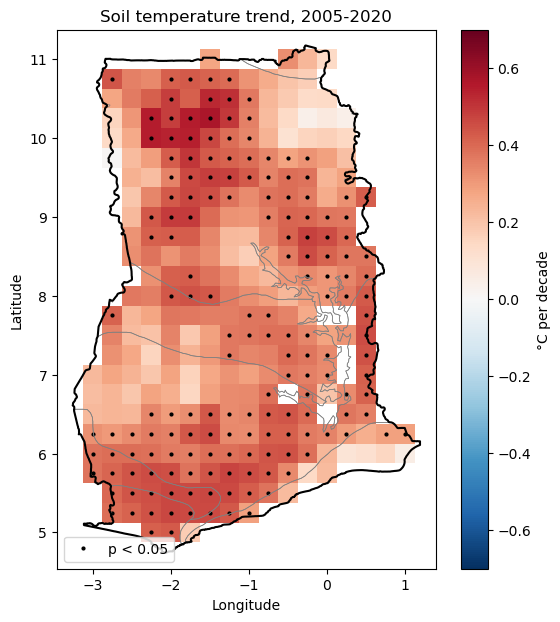

Ghana-wide median trend: +0.35 °C per decade
Cells with a significant trend: 56%


In [27]:
annual_T = soilT.groupby("time.year").mean("time")       # one soil-T map per year
years = annual_T["year"].values

# warming rate at every cell (slope of a straight line through the 16 yearly values) + its p-value
slope = np.full(valid.shape, np.nan)
p_map = np.full(valid.shape, np.nan)
for i in range(len(lat)):
    for j in range(len(lon)):
        if valid.values[i, j]:
            fit = stats.linregress(years, annual_T.values[:, i, j])
            slope[i, j] = fit.slope * 10          # per decade
            p_map[i, j] = fit.pvalue

slope_da = xr.DataArray(slope, coords={"latitude": lat, "longitude": lon}, dims=("latitude", "longitude"))

fig, ax = plt.subplots(figsize=(6.5, 7))
slope_da.plot(ax=ax, cmap="RdBu_r", vmin=-0.7, vmax=0.7, cbar_kwargs={"label": "°C per decade"})
ys, xs = np.where(p_map < 0.05)
ax.plot(lon[xs], lat[ys], "k.", markersize=4, label="p < 0.05")     # dots where the trend is significant
ax.legend(loc="lower left")
ax.set_title("Soil temperature trend, 2005-2020")
add_outline(ax)
plt.show()

print("Ghana-wide median trend: %+.2f °C per decade" % np.nanmedian(slope))
print("Cells with a significant trend: %.0f%%" % (np.mean(p_map[valid.values] < 0.05) * 100))

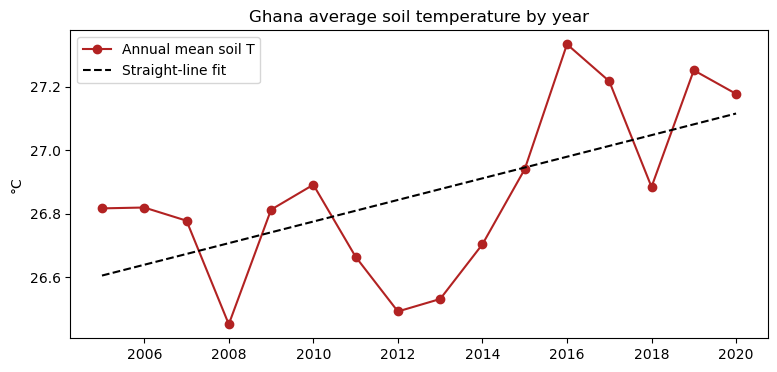

Warming rate: +0.34 °C per decade (p = 0.014)


In [28]:
ghana_annual_T = annual_T.mean(["latitude", "longitude"]).to_series()
fit = stats.linregress(years, ghana_annual_T.values)

plt.figure(figsize=(9, 4))
plt.plot(years, ghana_annual_T.values, "o-", color="firebrick", label="Annual mean soil T")
plt.plot(years, fit.intercept + fit.slope * years, "--", color="black", label="Straight-line fit")
plt.ylabel("°C"); plt.legend(); plt.title("Ghana average soil temperature by year")
plt.show()

print("Warming rate: %+.2f °C per decade (p = %.3f)" % (fit.slope * 10, fit.pvalue))

In [29]:
# average the z-scores over each group's cells -> one time series per group
rain_z_group  = pd.DataFrame(index=times)
soilT_z_group = pd.DataFrame(index=times)

for name in group_names:
    in_group = (group_map == name) & valid
    rain_z_group[name]  = rain_z.where(in_group).mean(["latitude", "longitude"]).values
    soilT_z_group[name] = soilT_z.where(in_group).mean(["latitude", "longitude"]).values

# and one for all of Ghana
rain_z_group["All Ghana"]  = rain_z.mean(["latitude", "longitude"]).values
soilT_z_group["All Ghana"] = soilT_z.mean(["latitude", "longitude"]).values

rain_z_group.head()

,Savanna,Transitional,Forest,Coastal savanna,All Ghana
2005-01-01,NaN,NaN,NaN,NaN,NaN
2005-02-01,NaN,NaN,NaN,NaN,NaN
2005-03-01,0.003166,0.358081,0.436322,1.022130,0.235034
2005-04-01,0.231051,0.525667,0.704246,1.142325,0.465952
2005-05-01,0.208762,0.735626,0.854957,0.798446,0.523532


In [30]:
# correlate rainfall z-score LAGGED by 0-4 months with soil-temperature z-score
# lag 2 means: rainfall two months ago vs soil temperature now
lags = [0, 1, 2, 3, 4]
row_names = group_names + ["All Ghana"]

r_table = pd.DataFrame(index=row_names, columns=lags, dtype=float)    # correlation
p_table = pd.DataFrame(index=row_names, columns=lags, dtype=float)    # p-value

for name in row_names:
    for lag in lags:
        pair = pd.concat([rain_z_group[name].shift(lag), soilT_z_group[name]], axis=1).dropna()
        r, p = stats.pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])
        r_table.loc[name, lag] = r
        p_table.loc[name, lag] = p

print("Correlation (r):")
display(r_table.round(2))
print("p-values (below 0.05 = 'significant'):")
display(p_table.round(3))

Correlation (r):


,0,1,2,3,4
Savanna,-0.13,-0.20,-0.21,-0.16,-0.17
Transitional,-0.05,-0.07,-0.13,-0.11,-0.10
Forest,-0.05,-0.09,-0.13,-0.13,-0.10
Coastal savanna,0.11,-0.00,-0.11,-0.16,-0.09
All Ghana,0.01,-0.07,-0.13,-0.14,-0.14


p-values (below 0.05 = 'significant'):


,0,1,2,3,4
Savanna,0.064,0.005,0.004,0.027,0.017
Transitional,0.493,0.324,0.074,0.117,0.181
Forest,0.478,0.203,0.076,0.065,0.172
Coastal savanna,0.139,0.981,0.135,0.025,0.236
All Ghana,0.884,0.338,0.075,0.051,0.062


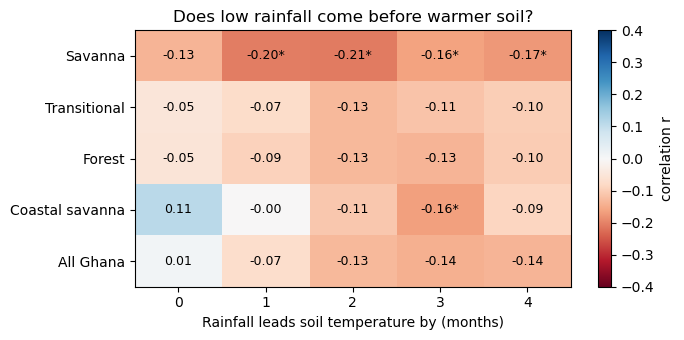

Tests run: 25 | significant at 0.05: 5 | expected by pure chance: 1.2


In [31]:
# heatmap of the correlations (* = p below 0.05)
fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(r_table.values, cmap="RdBu", vmin=-0.4, vmax=0.4, aspect="auto")

for i in range(len(row_names)):
    for j in range(len(lags)):
        star = "*" if p_table.values[i, j] < 0.05 else ""
        ax.text(j, i, f"{r_table.values[i, j]:.2f}{star}", ha="center", va="center", fontsize=9)

ax.set_xticks(range(len(lags)));      ax.set_xticklabels(lags)
ax.set_yticks(range(len(row_names))); ax.set_yticklabels(row_names)
ax.set_xlabel("Rainfall leads soil temperature by (months)")
plt.colorbar(im, label="correlation r")
plt.title("Does low rainfall come before warmer soil?")
plt.tight_layout()
plt.show()

print("Tests run:", r_table.size, "| significant at 0.05:", int((p_table.values < 0.05).sum()),
      "| expected by pure chance:", round(0.05 * r_table.size, 1))

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# one row per grid cell: its 12 monthly rainfall averages + 12 monthly soil-temperature averages
rain_cells  = rain_clim.stack(cell=("latitude", "longitude")).dropna("cell", how="any").transpose("cell", "month")
soilT_cells = soilT_clim.stack(cell=("latitude", "longitude")).dropna("cell", how="any").transpose("cell", "month")

features = np.hstack([rain_cells.values, soilT_cells.values])
features = StandardScaler().fit_transform(features)      # put all 24 numbers on the same scale

print("table of features (cells x numbers):", features.shape)

table of features (cells x numbers): (302, 24)


In [33]:
# how many clusters? try 2 to 6 and compare the silhouette score (higher = cleaner separation)
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, n_init=50, random_state=0).fit(features).labels_
    print("k =", k, " silhouette =", round(silhouette_score(features, labels_k), 3))

k = 2  silhouette = 0.478
k = 3  silhouette = 0.398
k = 4  silhouette = 0.352
k = 5  silhouette = 0.368
k = 6  silhouette = 0.316


In [34]:
K = 4      # same number of groups as our official groups, so we can compare them

kmeans = KMeans(n_clusters=K, n_init=50, random_state=0).fit(features)

# cluster numbers are arbitrary, so number them from north (0) to south (3)
cell_lat = rain_cells["latitude"].values
mean_lat = [cell_lat[kmeans.labels_ == k].mean() for k in range(K)]
order = np.argsort(mean_lat)[::-1]                        # northernmost cluster first
new_label = {old: new for new, old in enumerate(order)}
cluster = np.array([new_label[l] for l in kmeans.labels_])

print("cells in each cluster:", np.bincount(cluster))

cells in each cluster: [101  58  84  59]


In [35]:
# compare k-means clusters with the official groups
official = group_map.stack(cell=("latitude", "longitude")).sel(cell=rain_cells.cell).values

pd.crosstab(pd.Series(official, name="Official group"), pd.Series(cluster, name="k-means cluster"))

k-means cluster,0,1,2,3
Official group,,,,
Coastal savanna,0,0,10,0
Forest,0,2,46,59
Savanna,100,46,1,0
Transitional,1,10,27,0


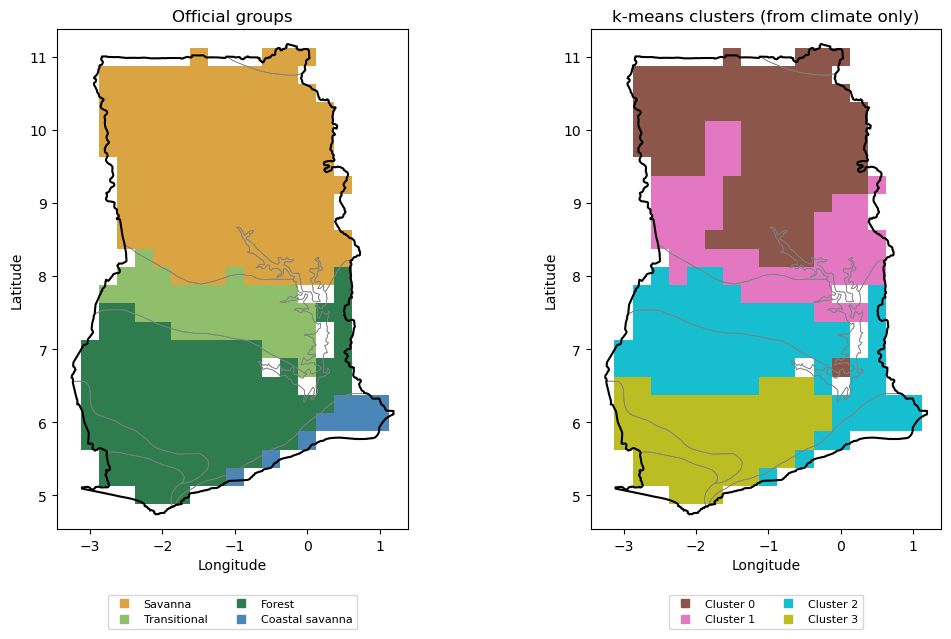

In [36]:
# put the cluster numbers back on the map grid
cluster_map = (xr.DataArray(cluster, coords={"cell": rain_cells.cell}, dims="cell")
                 .unstack("cell")
                 .reindex(latitude=lat, longitude=lon))

cluster_colors = ["#8c564b", "#e377c2", "#17becf", "#bcbd22"]

fig, axes = plt.subplots(1, 2, figsize=(11, 6.5))

# left: official groups (from Cell 9)
group_num.plot(ax=axes[0], cmap=ListedColormap([colors[n] for n in group_names]),
               vmin=-0.5, vmax=3.5, add_colorbar=False)
for name in group_names:
    axes[0].plot([], [], "s", color=colors[name], label=name)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
axes[0].set_title("Official groups")
add_outline(axes[0])

# right: k-means clusters
cluster_map.plot(ax=axes[1], cmap=ListedColormap(cluster_colors), vmin=-0.5, vmax=3.5, add_colorbar=False)
for k in range(K):
    axes[1].plot([], [], "s", color=cluster_colors[k], label="Cluster " + str(k))
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
axes[1].set_title("k-means clusters (from climate only)")
add_outline(axes[1])

plt.tight_layout()
plt.show()

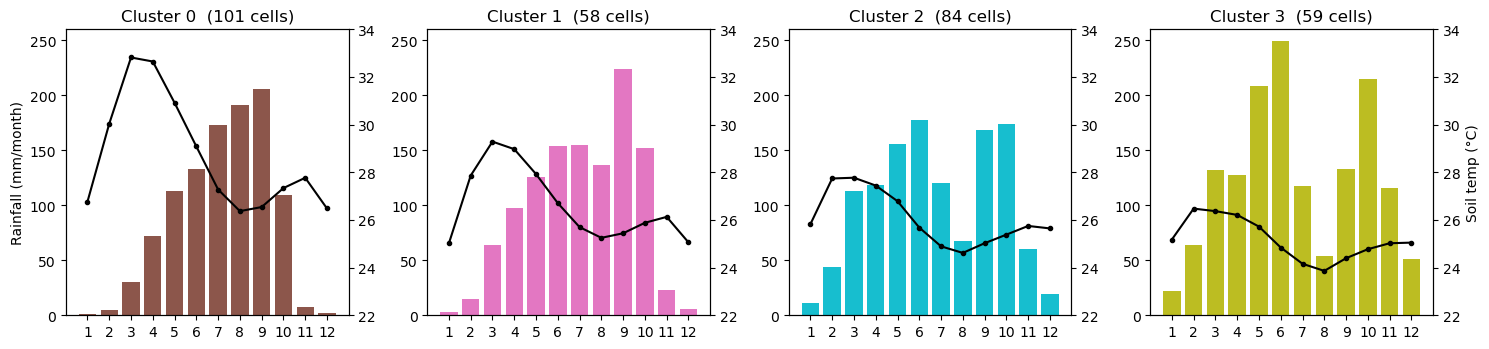

In [37]:
# what does each cluster look like? seasonal cycle of each cluster
fig, axes = plt.subplots(1, K, figsize=(15, 3.6))
for k, ax in enumerate(axes):
    in_cluster = (cluster_map == k)
    monthly_rain = rain_clim.where(in_cluster).mean(["latitude", "longitude"])
    monthly_temp = soilT_clim.where(in_cluster).mean(["latitude", "longitude"])

    ax.bar(range(1, 13), monthly_rain.values, color=cluster_colors[k])
    ax.set_ylim(0, 260)
    ax.set_xticks(range(1, 13))
    ax.set_title("Cluster " + str(k) + "  (" + str(int(in_cluster.sum())) + " cells)")

    ax2 = ax.twinx()
    ax2.plot(range(1, 13), monthly_temp.values, "k-o", markersize=3)
    ax2.set_ylim(22, 34)
axes[0].set_ylabel("Rainfall (mm/month)")
ax2.set_ylabel("Soil temp (°C)")
plt.tight_layout()
plt.show()